In [1]:
import pandas as pd 
df = pd.read_csv("heart_disease.csv")
print(df.head())
print(df["target"].value_counts())

   age  sex  cp  trestbps  chol  fbs  thalach  exang  oldpeak  ca  target
0   49    0   3       177   150    0       95      0      2.3   0       0
1   56    1   0       124   172    1       86      1      0.5   0       1
2   66    0   3       100   239    0      105      0      1.7   0       0
3   64    0   0       168   222    0       95      1      2.8   0       1
4   60    1   2       153   358    0      147      0      3.2   0       1
1    15
0    10
Name: target, dtype: int64


In [2]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       25 non-null     int64  
 1   sex       25 non-null     int64  
 2   cp        25 non-null     int64  
 3   trestbps  25 non-null     int64  
 4   chol      25 non-null     int64  
 5   fbs       25 non-null     int64  
 6   thalach   25 non-null     int64  
 7   exang     25 non-null     int64  
 8   oldpeak   25 non-null     float64
 9   ca        25 non-null     int64  
 10  target    25 non-null     int64  
dtypes: float64(1), int64(10)
memory usage: 2.3 KB
None
             age        sex         cp    trestbps        chol        fbs  \
count  25.000000  25.000000  25.000000   25.000000   25.000000  25.000000   
mean   60.920000   0.560000   1.560000  172.720000  287.800000   0.320000   
std    17.755093   0.506623   1.293574   69.076962  101.348409   0.476095   
min    29.000000   0.00000

In [3]:
df.dropna()
df.fillna(df.mean())
df.fillna(method='ffill')

,age,sex,cp,trestbps,chol,fbs,thalach,exang,oldpeak,ca,target
0,49,0,3,177,150,0,95,0,2.3,0,0
1,56,1,0,124,172,1,86,1,0.5,0,1
2,66,0,3,100,239,0,105,0,1.7,0,0
3,64,0,0,168,222,0,95,1,2.8,0,1
4,60,1,2,153,358,0,147,0,3.2,0,1
5,48,1,2,187,355,0,89,0,2.0,0,1
6,38,1,3,99,165,0,158,1,1.4,2,1
7,58,0,0,128,368,0,86,1,2.8,2,1
8,53,1,0,153,307,0,100,0,0.2,1,0
9,44,1,3,157,167,0,185,0,2.2,0,1


In [4]:
x = df.drop("target",axis=1)
y = df["target"]
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [5]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter = 1000)
model.fit(x_train, y_train)
pred = model.predict(x_test)
print(pred[:10])

[0 1 1 0 1]


In [6]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)
print("Coefficient:", model.coef_)
print("Intercept:",model.intercept_)

Coefficient: [-4.50063351e-03  5.62535158e-02  6.66724322e-02 -2.25733660e-04
  8.19951786e-04  1.00395290e-02 -6.98376971e-04  3.01987324e-01
  1.39660351e-01 -1.91632327e-01]
Intercept: 0.47463426153940375


In [7]:
y_pred=model.predict(x_test)
print(y_pred[:5])
print(y_test.values[:5])

[0.2760042  0.81717276 0.79203142 0.51618121 0.68599034]
[0 1 0 0 1]


In [8]:
from sklearn.metrics import(mean_absolute_error, mean_squared_error,r2_score)
import numpy as np
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
print("MAE:",mae,"MSE:",mse,"RMSE:",rmse,"R2:",r2)

MAE: 0.416210744846078 MSE: 0.22039259935468233 RMSE: 0.46945990175379443 R2: 0.0816975026888237


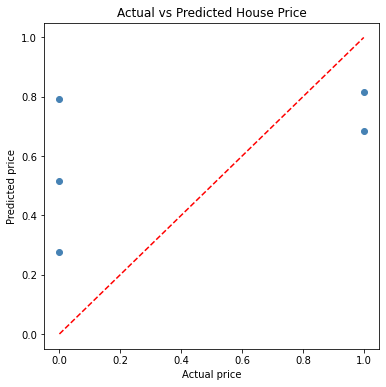

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize = (6,6))
plt.scatter(y_test,y_pred,color ='steelblue')
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],"r--")
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title("Actual vs Predicted House Price")
plt.show()

In [10]:
from sklearn.metrics import(accuracy_score, confusion_matrix, precision_score, recall_score, f1_score)
acc = accuracy_score(y_test, pred)
cm = confusion_matrix(y_test, pred)
prec = precision_score(y_test, pred)
rec = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)
print(acc, prec, rec, f1)
print(cm)

0.8 0.6666666666666666 1.0 0.8
[[2 1]
 [0 2]]


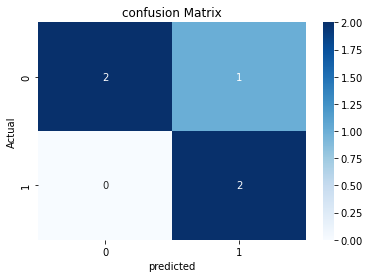

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(cm, annot = True, fmt = "d", cmap = "Blues")
plt.xlabel("predicted")
plt.ylabel("Actual")
plt.title("confusion Matrix")
plt.show()

In [12]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors = 5)
knn.fit(x_train, y_train)
pred_knn = knn.predict(x_test)
print(accuracy_score(y_test, pred_knn))

0.4


In [13]:
for k in [1, 3, 5, 7]:
    knn = KNeighborsClassifier(n_neighbors = k)
    knn.fit(x_train, y_train)
    pred_k = knn.predict(x_test)
    acc_k = accuracy_score(y_test, pred_k)
    print("k=", k,"->Accuracy:",acc_k)    

k= 1 ->Accuracy: 0.2
k= 3 ->Accuracy: 0.2
k= 5 ->Accuracy: 0.4
k= 7 ->Accuracy: 0.4


In [14]:
import joblib
joblib.dump(model,"model.pkl")
print("model saved")

model saved


In [15]:
pip install streamlit

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
daal4py 2021.5.0 requires daal==2021.4.0, which is not installed.
scipy 1.7.3 requires numpy<1.23.0,>=1.16.5, but you have numpy 2.0.2 which is incompatible.
numba 0.55.1 requires numpy<1.22,>=1.18, but you have numpy 2.0.2 which is incompatible.



  Using cached streamlit-1.50.0-py3-none-any.whl (10.1 MB)
  Using cached altair-5.5.0-py3-none-any.whl (731 kB)
  Attempting uninstall: typing-extensions
    Found existing installation: typing-extensions 4.1.1
    Uninstalling typing-extensions-4.1.1:
      Successfully uninstalled typing-extensions-4.1.1
  Attempting uninstall: numpy
    Found existing installation: numpy 1.21.5
    Uninstalling numpy-1.21.5:
      Successfully uninstalled numpy-1.21.5
  Attempting uninstall: tenacity
    Found existing installation: tenacity 8.0.1
    Uninstalling tenacity-8.0.1:
      Successfully uninstalled tenacity-8.0.1
  Attempting uninstall: protobuf
    Found existing installation: protobuf 3.19.1
    Uninstalling protobuf-3.19.1:
      Successfully uninstalled protobuf-3.19.1


In [24]:
import streamlit as st
import joblib
import numpy as np
model = joblib.load("model.pkl")

st.title("Heart Disease prediction app")
st.write("Enter the heart disease details below to get a predicted disease.")
age = st.number_input("Age", min_value = 29, max_value = 98, value = 30)
sex = st.number_input("Sex", min_value = 0, max_value = 1,value = 0)
cp = st.number_input("Cp", min_value = 0, max_value = 3, value = 0)
trestbps = st.number_input("Trestbps", min_value = 123, max_value = 356, value = 123)
chol = st.number_input("Chol", min_value = 123, max_value = 456, value = 123 )
fbs = st.number_input("Fbs", min_value = 0, max_value = 1, value = 0)
thalach = st.number_input("Thalach", min_value = 84, max_value = 234, value = 84)
exang = st.number_input("Exang", min_value = 0, max_value = 1, value = 0)
oldpeak = st.number_input("Oldpeak", min_value = 0, max_value = 3, value = 2)
ca = st.number_input("Ca", min_value = 0, max_value = 2, value = 1)

if st.button("Predict Disease"):
    data = np.array([[age, sex, cp, tresbps, chol, fbs, thalach, exang, oldpeak, ca]])
    prediction = model.predict(data)
    st.success(f"Predicted Disease: {prediction[0]:,.0f}")
st.caption("Model: Linear Regression | Trained on heart_disease.csv")


2026-09-30 15:56:33.016 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-30 15:56:33.017 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-30 15:56:33.018 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-30 15:56:33.021 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-30 15:56:33.030 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-30 15:56:33.030 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-30 15:56:33.038 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-30 15:56:33.038 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()